#  Modèle Baseline 3 — CamemBERT Frozen + Logistic Regression
**Pipeline** : CamemBERT (gelé, pas de fine-tuning) → Extraction embedding CLS (768 dims) → LogisticRegression
Ce modèle sert de pont entre les baselines classiques et le fine-tuning complet.

In [1]:
# ═══════════════════════════════════════════════════════
# SETUP
# ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Projet_Sentiment_Analysis'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
FIG_DIR     = os.path.join(PROJECT_DIR, 'figures')

!pip install -q transformers

import pandas as pd
import numpy as np
import torch
from transformers import CamembertTokenizer, CamembertModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")

Mounted at /content/drive
✅ Device : cuda


In [2]:
# ═══════════════════════════════════════════════════════
# CHARGER CAMEMBERT (FROZEN)
# ═══════════════════════════════════════════════════════
print("📥 Chargement de CamemBERT...")
tokenizer = CamembertTokenizer.from_pretrained('camembert-base')
model_bert = CamembertModel.from_pretrained('camembert-base')
model_bert.to(DEVICE)
model_bert.eval()  # Mode évaluation = pas de dropout, pas de gradient

print("✅ CamemBERT chargé (frozen)")

# Charger les données
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

📥 Chargement de CamemBERT...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CamemBERT chargé (frozen)


In [3]:
# ═══════════════════════════════════════════════════════
# EXTRACTION DES EMBEDDINGS CLS
# ═══════════════════════════════════════════════════════

def extract_embeddings(textes, batch_size=32, max_length=128):
    """
    Extrait l'embedding CLS de CamemBERT pour chaque texte.
    Retourne un array numpy de shape (n_textes, 768).
    """
    all_embeddings = []

    for i in tqdm(range(0, len(textes), batch_size), desc="Extraction"):
        batch_textes = textes[i:i+batch_size].tolist()

        # Tokeniser
        encoded = tokenizer(
            batch_textes,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(DEVICE)

        # Extraire les embeddings sans gradient (économise la mémoire)
        with torch.no_grad():
            outputs = model_bert(**encoded)
            # Prendre le token CLS (position 0) du dernier layer
            cls_embeddings = outputs.last_hidden_state[:, 0, :]

        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

print("✅ Fonction d'extraction définie")

✅ Fonction d'extraction définie


In [4]:
# ═══════════════════════════════════════════════════════
# EXTRACTION (PREND ~20 MIN SUR GPU)
# ═══════════════════════════════════════════════════════
print(" Extraction des embeddings du train set...")
X_train_emb = extract_embeddings(df_train['texte_clean'].fillna('').values)

print("\n Extraction des embeddings du val set...")
X_val_emb = extract_embeddings(df_val['texte_clean'].fillna('').values)

print("\n Extraction des embeddings du test set...")
X_test_emb = extract_embeddings(df_test['texte_clean'].fillna('').values)

print(f"\n Shapes : Train {X_train_emb.shape} | Val {X_val_emb.shape} | Test {X_test_emb.shape}")

# Sauvegarder les embeddings pour ne pas recalculer
np.save(os.path.join(DATA_DIR, 'train_embeddings.npy'), X_train_emb)
np.save(os.path.join(DATA_DIR, 'val_embeddings.npy'), X_val_emb)
np.save(os.path.join(DATA_DIR, 'test_embeddings.npy'), X_test_emb)
print("✅ Embeddings sauvegardés sur Drive")

🚀 Extraction des embeddings du train set...


Extraction: 100%|██████████| 291/291 [00:43<00:00,  6.76it/s]



🚀 Extraction des embeddings du val set...


Extraction: 100%|██████████| 37/37 [00:05<00:00,  6.75it/s]



🚀 Extraction des embeddings du test set...


Extraction: 100%|██████████| 37/37 [00:05<00:00,  6.42it/s]



📊 Shapes : Train (9285, 768) | Val (1161, 768) | Test (1161, 768)
✅ Embeddings sauvegardés sur Drive


🚀 Entraînement LogisticRegression...
✅ Entraînement terminé

📊 RÉSULTATS — CamemBERT Frozen + LogReg
   Accuracy  : 0.7606
   F1-macro  : 0.6314

📋 Classification Report :
              precision    recall  f1-score   support

     négatif       0.83      0.74      0.78       395
      neutre       0.18      0.43      0.25        84
     positif       0.91      0.82      0.86       682

    accuracy                           0.76      1161
   macro avg       0.64      0.66      0.63      1161
weighted avg       0.83      0.76      0.79      1161



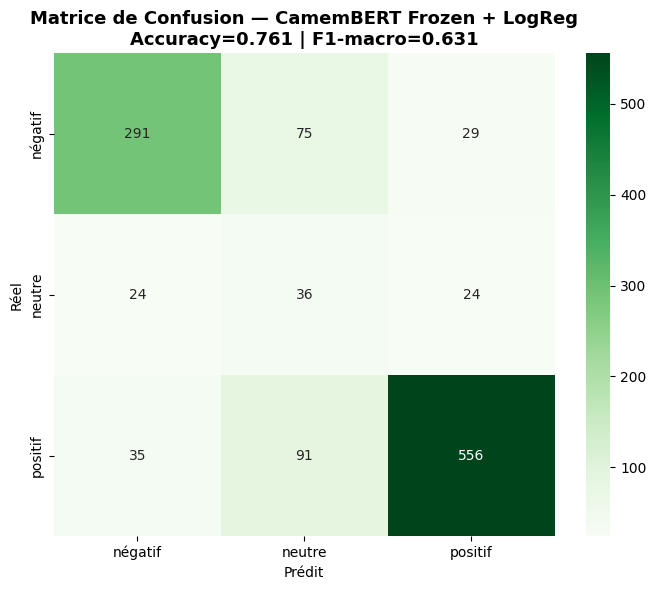

In [5]:
# ═══════════════════════════════════════════════════════
# LOGISTIC REGRESSION SUR LES EMBEDDINGS
# ═══════════════════════════════════════════════════════
print("🚀 Entraînement LogisticRegression...")

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=1.0,
    random_state=42,
    solver='lbfgs',
    multi_class='multinomial'
)

lr_model.fit(X_train_emb, y_train)
print("✅ Entraînement terminé")

# Évaluation
val_preds  = lr_model.predict(X_val_emb)
test_preds = lr_model.predict(X_test_emb)

test_acc = accuracy_score(y_test, test_preds)
test_f1  = f1_score(y_test, test_preds, average='macro')

print("\n" + "="*60)
print("📊 RÉSULTATS — CamemBERT Frozen + LogReg")
print("="*60)
print(f"   Accuracy  : {test_acc:.4f}")
print(f"   F1-macro  : {test_f1:.4f}")
print(f"\n Classification Report :")
print(classification_report(y_test, test_preds, target_names=['négatif','neutre','positif']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['négatif','neutre','positif'],
            yticklabels=['négatif','neutre','positif'])
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de Confusion — CamemBERT Frozen + LogReg\nAccuracy={test_acc:.3f} | F1-macro={test_f1:.3f}',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_camembert_frozen.png'), dpi=150, bbox_inches='tight')
plt.show()